# Climate, Human Exposure, and Shark Incident Trends

## Project Overview

This project investigates how shark incident trends relate to climate patterns, population growth, and human coastal exposure.

The analysis explores:
- long-term shark incident trends
- Florida-specific incident patterns
- population-normalized risk
- global temperature anomalies
- regional environmental comparisons

## Core Research Question

Are shark incident trends better explained by environmental change, increased human exposure, or a combination of both?

## Data Sources

### Shark Incident Data
Shark incident records were obtained from the Global Shark Attack File (GSAF), a publicly maintained international database documenting reported shark incidents worldwide.

### Ocean Temperature Data
Ocean temperature anomaly data was obtained from NOAA Climate at a Glance.

### Florida Population Data
Florida population data was obtained from publicly available demographic records based on U.S. Census estimates.

## Shark data loading and cleaning

In [152]:
import pandas as pd
new_df = pd.read_csv("/Users/claygrant/Desktop/climate_shark_analytics/data/Shark_attacks.csv", low_memory=False)
new_df = new_df.dropna(axis=1, how="all")
new_df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29-May-25,2025.0,Unprovoked,USA,North Carolina,Sunset Beach,Swimming,Sean Barton,M,26,...,Not stated,Kevin McMurray Trackingsharks.com: Clay Crewel...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15-May-25,2025.0,Unprovoked,Australia,South Australia,Port Noarlunga,Swimming,Richard Vinall,M,66,...,Not stated,Simon DeMarchi: Todd Smith: 9 News:ABC News,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8-May-25,2025.0,Unprovoked,Jamaica,Montego Bay,Rose Hall beach,Paddling,Rachel Smith,F,26,...,Small shark 1m (3ft) long,The sun News: Metro: Kevin McMurray Tracking s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21-Apr-25,2025.0,Unprovoked,Israel,Hadera,Olga Beach near Hadera Stream,Diving,Barak Tzach,M,45,...,Dusky sharks,Ynetnews.com: Dailymirroe.co.uk: Todd Smith Al...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20-Apr-25,2025.0,Questionable,Mexico,Quntana Roo,Chac Mool Beach Cancun,Rescuing female companion,Alejandro Cortes,M,20,...,Not Staed,"Mundo Now: Reutir"" Kevin McMurray Trackingshar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Global Shark Incident Trends

This section examines how reported shark incidents have changed over time on a global scale.

The purpose is to identify long-term trends and establish a baseline understanding before incorporating population growth or environmental variables into the analysis.

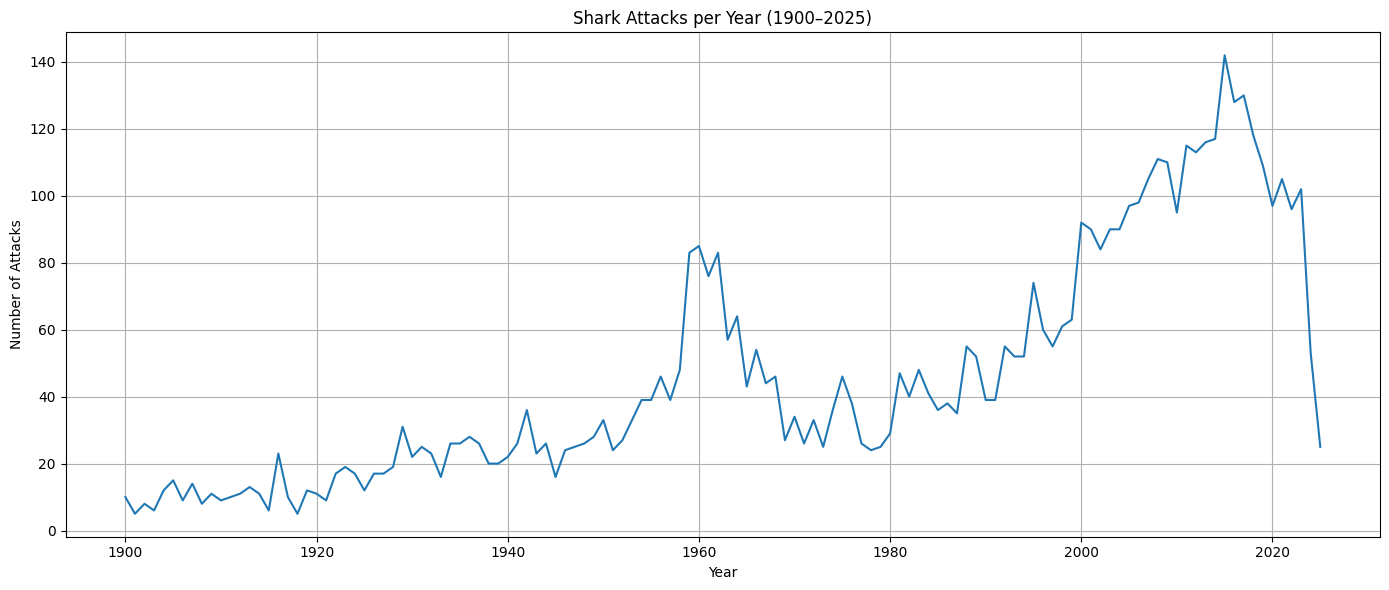

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

new_df['Date'] = pd.to_datetime(new_df['Date'], format='mixed',errors='coerce')
new_df['Year'] = new_df['Date'].dt.year

new_df = new_df.dropna(subset=['Year'])


attacks_by_year = new_df.groupby('Year').size().reset_index(name='Attack Count')

attacks_by_year = attacks_by_year[(attacks_by_year['Year'] >= 1900) & (attacks_by_year['Year'] <= 2025)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=attacks_by_year, x='Year', y='Attack Count')
plt.title('Shark Attacks per Year (1900–2025)')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.tight_layout()
plt.show()

## Global Shark Incident per Year Interpretation

Reported shark incidents show a log term upward trend over time. However, raw incident counts alone do not necessarily indicate increased shark aggression or population growth.

Several factors may contribute to observed increase, including but not limited to:
- rising coastal populations,
- increased ocean recreation,
- improved reporting systems,
- and broader environmental changes yet to be explored in this analysis.

Because incident frequency is influenced by both humna and environmental conditions, additional variables need to be explored.

## Australia Regional Case Study

This section isolates shark incident data from Australia to compare regional trends against other locations such as Florida.

Regional comparisons help determine whether observed increases in shark incidents are geographically consistent or potentially influenced by local environmental and demographic factors.

In [93]:
df_aus = new_df[new_df['Country'] == 'Australia']
df_aus.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Unnamed: 245,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254
1,2025-05-15,2025.0,Unprovoked,Australia,South Australia,Port Noarlunga,Swimming,Richard Vinall,M,66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2025-03-26,2025.0,Unprovoked,Australia,WA,Sandtrax Port Beach North Fremantle Perth,Swimming,Unknown Male,M,30+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2025-03-10,2025.0,Unprovoked,Australia,WA,Duke of Orleans Bay,Surfing,Steven Jeffrey Payne,M,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2025-03-07,2025.0,Unprovoked,Australia,NSW,Gunyah beach Bundeena Port Hacking,Swimming,Mangyong Zhang,F,56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,2025-02-27,2025.0,Unprovoked,Australia,Victoria,Nuns Beach near Portland,Swimming,Robbie Houlihan,M,40+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
state_counts = df_aus['State'].value_counts()

print(state_counts)

State
Western Australia    6
Queensland           5
South Australia      3
NSW                  3
WA                   2
Victoria             1
New South Wales      1
Name: count, dtype: int64


In [119]:
df_aus['Date'] = pd.to_datetime(df_aus['Date'], errors='coerce')

df_aus = df_aus.dropna(subset = ['Date'])

df_aus['Year'] = df_aus['Date'].dt.year

aus_attacks_by_year = df_aus.groupby('Year').size().reset_index(name='Attack Count')

aus_attacks_by_year

,Year,Attack Count
0,2017,1
1,2024,8
2,2025,12


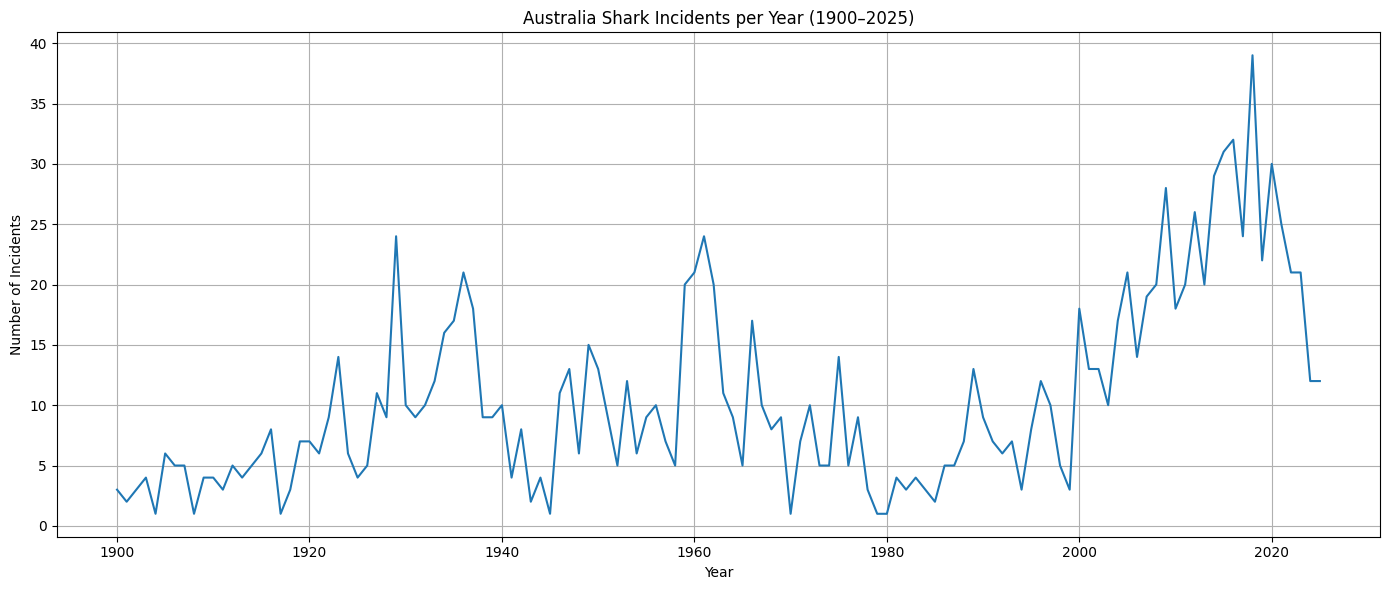

In [154]:
df_aus = new_df[new_df["Country"].str.upper().str.strip() == "AUSTRALIA"].copy()

# Group incidents by year
aus_attacks_by_year = (df_aus.groupby("Year").size().reset_index(name="Attack Count"))

# Restrict years
aus_attacks_by_year = aus_attacks_by_year[(aus_attacks_by_year["Year"] >= 1900) &(aus_attacks_by_year["Year"] <= 2025)]

# Plot
plt.figure(figsize=(14,6))

sns.lineplot(data=aus_attacks_by_year,x="Year",y="Attack Count")

plt.title("Australia Shark Incidents per Year (1900–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")

plt.grid(True)
plt.tight_layout()
plt.show()


### Australia Shark Incident Interpretation

Australia shows substantial long-term variability in reported shark incidents, with several periods of elevated activity occurring throughout the 20th and early 21st centuries.

Unlike a smooth linear trend, the data fluctuates considerably across decades, suggesting that shark incident frequency is influenced by a combination of environmental conditions, coastal activity, reporting practices, and regional behavioral patterns.

Incident frequency appears to increase in the late 1990s and 2000s, although yearly variability remains high. This highlights the difficulty of interpreting raw incident totals without considering broader contextual factors such as population growth and human exposure to marine environments.

Because Florida represents another globally significant region for shark incidents — while also offering accessible population and environmental datasets — the following section shifts toward a more detailed Florida case study focused on population-adjusted risk and environmental comparison.

## Florida case study
Florida was selected as a focused case study due to its high concentration of reported shark incidents and substantial long-term coastal population growth.

Analyzing Florida separately allows environmental trends to be compared alongside changes in human exposure over time.

In [96]:
df_usa = new_df[new_df['Country'] == 'USA']
df_usa.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Unnamed: 245,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254
0,2025-05-29,2025.0,Unprovoked,USA,North Carolina,Sunset Beach,Swimming,Sean Barton,M,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-04-12,2025.0,Unprovoked,USA,Florida,Everglades National Park Flamingo Lodge Highwa...,Undisclosed,Unknown Male,M,?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,2025-01-11,2025.0,Provoked,USA,Hawaii,Off Haleiwa Boat Harbour Oahu,Diving,Male not stated was a dive tour worker,M,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,2024-10-25,2024.0,Unprovoked,USA,Florida,"Bathtub Beach, Martin County",Surfing,Cole Taschman,M,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,2024-10-11,2024.0,Unprovoked,USA,Florida,Brevard County Orlando,Surfing,Teddy Witteman,M,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
df_florida = df_usa[df_usa['State'] == 'Florida']
df_florida.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Unnamed: 245,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254
6,2025-04-12,2025.0,Unprovoked,USA,Florida,Everglades National Park Flamingo Lodge Highwa...,Undisclosed,Unknown Male,M,?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,2024-10-25,2024.0,Unprovoked,USA,Florida,"Bathtub Beach, Martin County",Surfing,Cole Taschman,M,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,2024-10-11,2024.0,Unprovoked,USA,Florida,Brevard County Orlando,Surfing,Teddy Witteman,M,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,2024-07-08,2024.0,Unprovoked,USA,Florida,Ponce de Leon Inlet Volusia County,Diving into Water,Dempsey Manhart,M,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,2024-07-05,2024.0,Unprovoked,USA,Florida,New Smyrna Beach,Wading,Not stated,M,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
df_florida['Date'] = pd.to_datetime(df_florida['Date'], errors='coerce')

df_florida = df_florida.dropna(subset = ['Date'])

df_florida['Year'] = df_florida['Date'].dt.year

fl_attacks_by_year = df_florida.groupby('Year').size().reset_index(name='Attack Count')

fl_attacks_by_year

,Year,Attack Count
0,1780,1
1,1849,2
2,1857,1
3,1881,1
4,1882,1
...,...,...
102,2021,30
103,2022,24
104,2023,22
105,2024,7


<module 'matplotlib.pyplot' from '/Users/claygrant/Documents/my_data_project/jhub_env/lib/python3.9/site-packages/matplotlib/pyplot.py'>

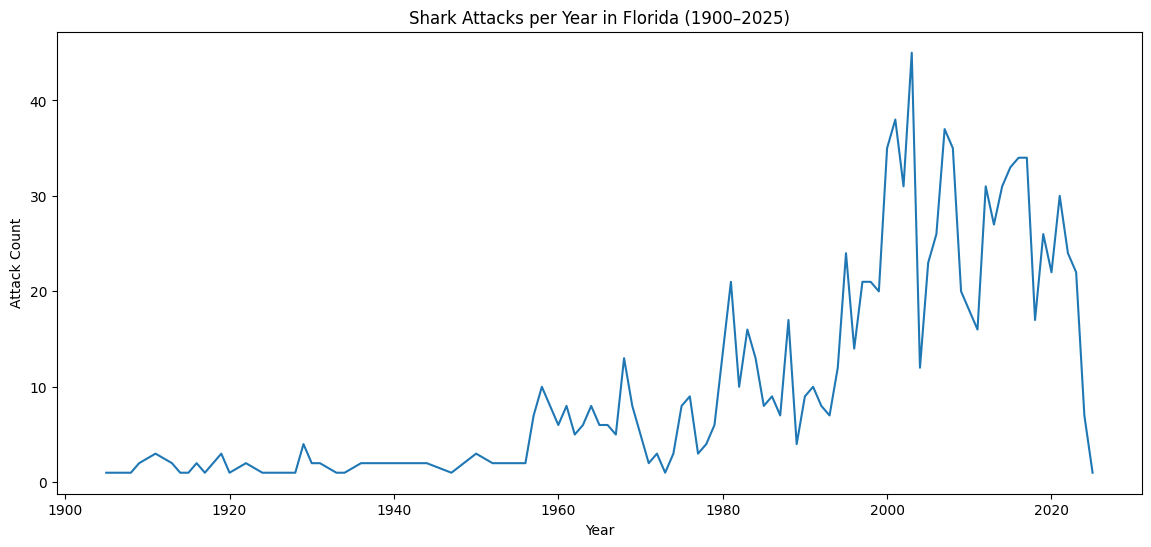

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

fl_attacks_by_year_trimmed = fl_attacks_by_year[(fl_attacks_by_year['Year'] >= 1900) & (fl_attacks_by_year['Year'] <= 2025)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=fl_attacks_by_year_trimmed, x='Year', y='Attack Count')
plt.title('Shark Attacks per Year in Florida (1900–2025)')
plt

### Florida Shark Attack per Year Plot Interpretation

Florida consistently represents one of the highest concentrations of reported shark incidents globally. 

As tourism and costal development expanded through the 20th century, opportunities for for human-shark interaction also increased. 

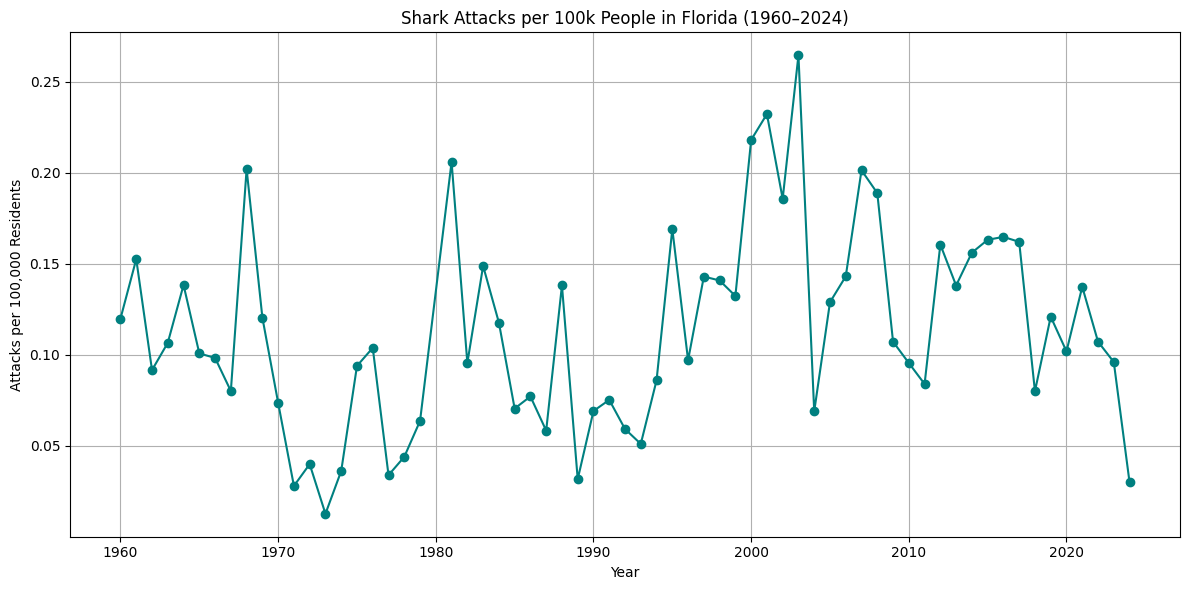

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

population_df = pd.read_csv("/Users/claygrant/Desktop/climate_shark_analytics/data/florida_population_1960_2024.csv")

merged_df = pd.merge(fl_attacks_by_year_trimmed, population_df, on="Year")

merged_df["Attacks_per_100k"] = (merged_df["Attack Count"] / merged_df["Population"]) * 100000

plt.figure(figsize=(12, 6))
plt.plot(merged_df["Year"], merged_df["Attacks_per_100k"], marker='o', linestyle='-', color='teal')
plt.title("Shark Attacks per 100k People in Florida (1960–2024)")
plt.xlabel("Year")
plt.ylabel("Attacks per 100,000 Residents")
plt.grid(True)
plt.tight_layout()
plt.show()

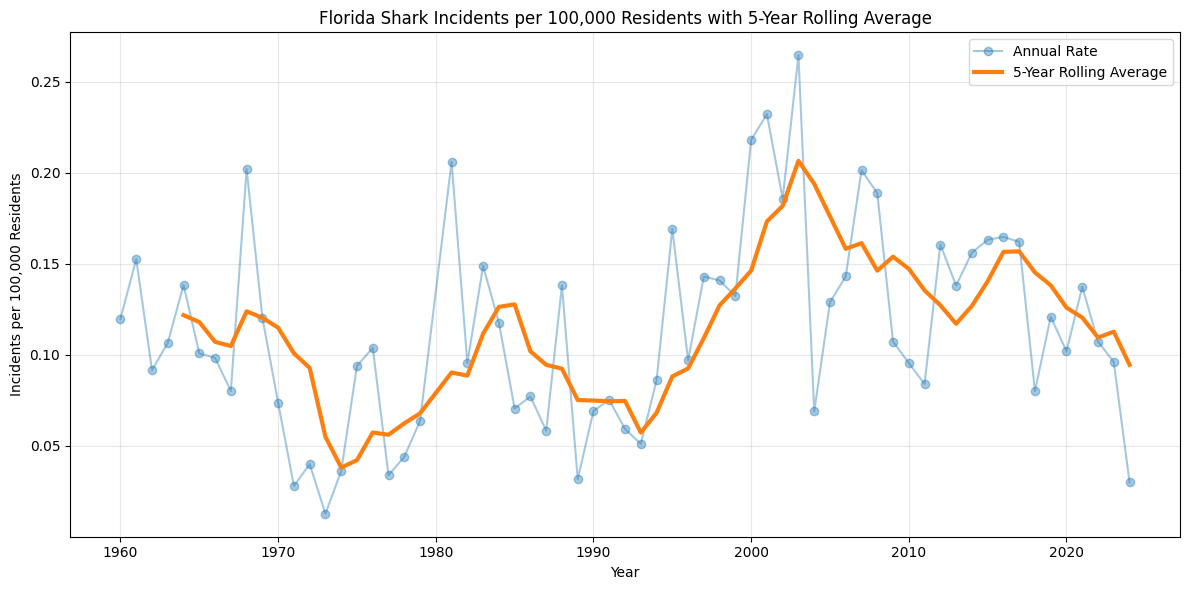

In [151]:
merged_df['Rolling_5yr'] = merged_df["Attacks_per_100k"].rolling(window = 5).mean()
plt.figure(figsize=(12, 6))
plt.plot(merged_df["Year"], merged_df["Attacks_per_100k"], alpha=0.4, marker="o", label="Annual Rate")
plt.plot(merged_df["Year"], merged_df["Rolling_5yr"], linewidth=3, label="5-Year Rolling Average")
plt.title("Florida Shark Incidents per 100,000 Residents with 5-Year Rolling Average")
plt.xlabel("Year")
plt.ylabel("Incidents per 100,000 Residents")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Shark Incidents per 100k People in Florida (population adjusted) plot Interpretation

While raw shark incident totals increase over time, population-adjusted incident rates are highly variable across decades.

The rolling-average trend shows periods of elevated relative shark incident frequency, particularly during the late 1990s and early 2000s.

### The long-term trend does not indicate a simple continuous increase in population-adjusted shark incident risk.

This suggests that Florida’s population growth and increased coastal activity may account for a substantial portion of the long-term increase observed in total reported shark incidents.

Rather than indicating a dramatic increase in relative shark attack risk, the normalized data suggests that increased human exposure to coastal environments is likely an important contributing factor.

### The average person's relative exposure risk may not have increased dramatically. 

In [101]:
import pandas as pd

temp_df = pd.read_csv("/Users/claygrant/Desktop/climate_shark_analytics/data/global_temps.csv")

temp_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.09,-0.17,-0.10,-0.21,-0.18,-0.11,-0.15,-0.24,-0.22,-0.18,-0.17,NaN,NaN,-0.12,-0.17,-0.20
1,1881,-0.20,-0.15,0.03,0.05,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.08,-0.09,-0.10,-0.18,0.04,-0.08,-0.19
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.22,-0.17,-0.08,-0.15,-0.24,-0.17,-0.36,-0.11,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.19,-0.18,-0.08,-0.08,-0.14,-0.23,-0.12,-0.24,-0.11,-0.18,-0.20,-0.34,-0.17,-0.10,-0.20
4,1884,-0.13,-0.09,-0.37,-0.40,-0.34,-0.35,-0.31,-0.28,-0.28,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.32,-0.29


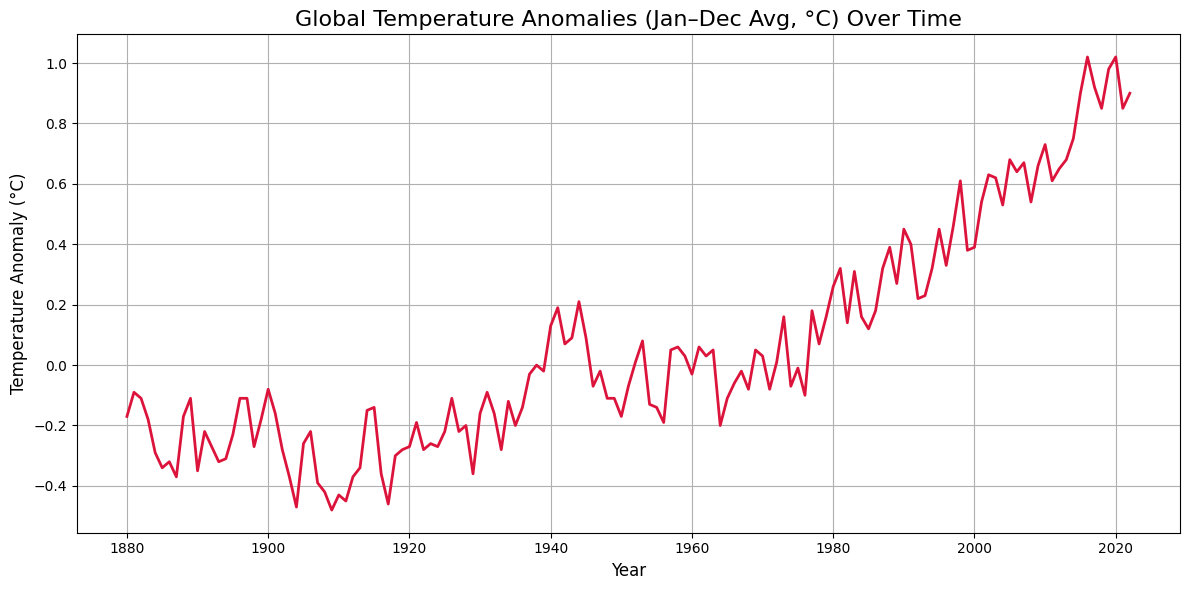

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

temp_df = pd.read_csv("global_temps.csv")

temp_df = temp_df[["Year", "J-D"]].dropna()

temp_df.rename(columns={"J-D": "Global_Temp_Anomaly"}, inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(temp_df["Year"], temp_df["Global_Temp_Anomaly"], color='crimson', linewidth=2)
plt.title("Global Temperature Anomalies (Jan–Dec Avg, °C) Over Time", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Temperature Anomaly (°C)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Global Temp Interpretation

Global temperature anomalies show a strong long-term warming trend, particularly beginning in the late 20th century. Recent decades contain some of the highest recorded anomaly values in the dataset.

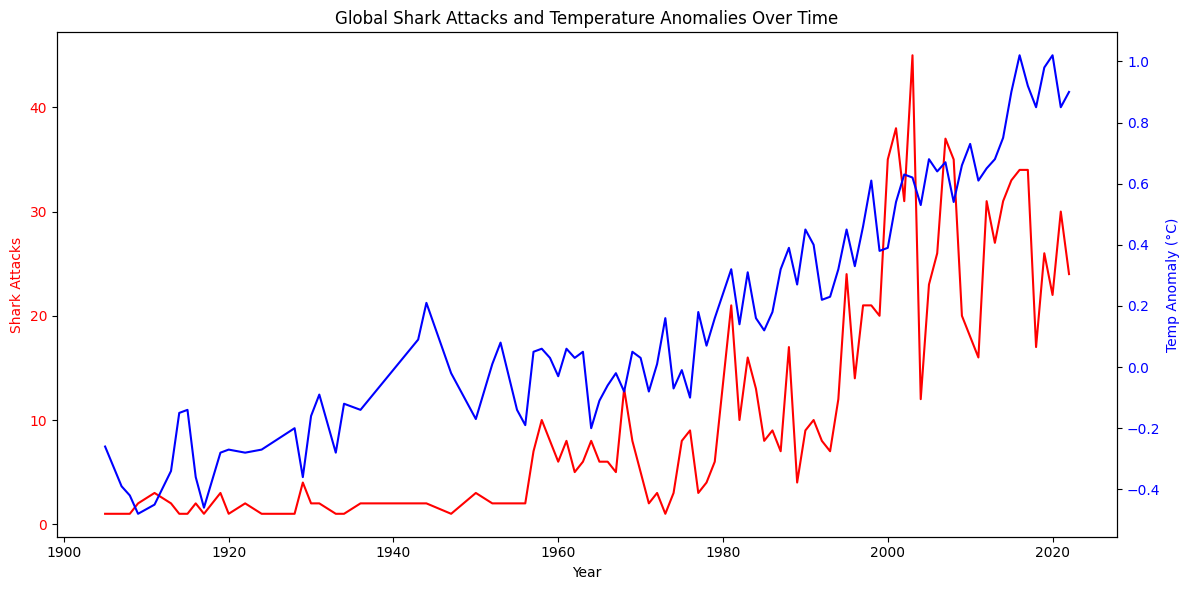

In [103]:
sst_merged_df = pd.merge(attacks_by_year, temp_df, on="Year")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(sst_merged_df["Year"], sst_merged_df["Attack Count"], color='red', label='Shark Attacks')
ax1.set_xlabel("Year")
ax1.set_ylabel("Shark Attacks", color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(sst_merged_df["Year"], sst_merged_df["Global_Temp_Anomaly"], color='blue', label='Temp Anomaly')
ax2.set_ylabel("Temp Anomaly (°C)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Global Shark Attacks and Temperature Anomalies Over Time")
fig.tight_layout()
plt.show()

### Global Shark Attacks and Temperature Anomalies Over Time Interpretation

Both global land temperatures and shark attacks have increased over time, but does that mean there is a correlation? It is important to investigate ocean temperatures rather than just overall global temperatures and see if we can draw any conclusions from comparing ocean temperature trends to shark incident trends.

In [144]:
ocean_temp_df = pd.read_csv("data.csv",skiprows=4,header=None)
ocean_temp_df.columns = ["Year", "Temp_Anomaly"]
ocean_temp_df.head()

,Year,Temp_Anomaly
0,1960,0.05
1,1961,0.06
2,1962,0.06
3,1963,0.03
4,1964,0.05


In [145]:
ocean_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          67 non-null     int64  
 1   Temp_Anomaly  67 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.2 KB


In [146]:
ocean_temp_df["Year"] = ocean_temp_df["Year"].astype(int)
ocean_temp_df["Temp_Anomaly"] = ocean_temp_df["Temp_Anomaly"].astype(float)

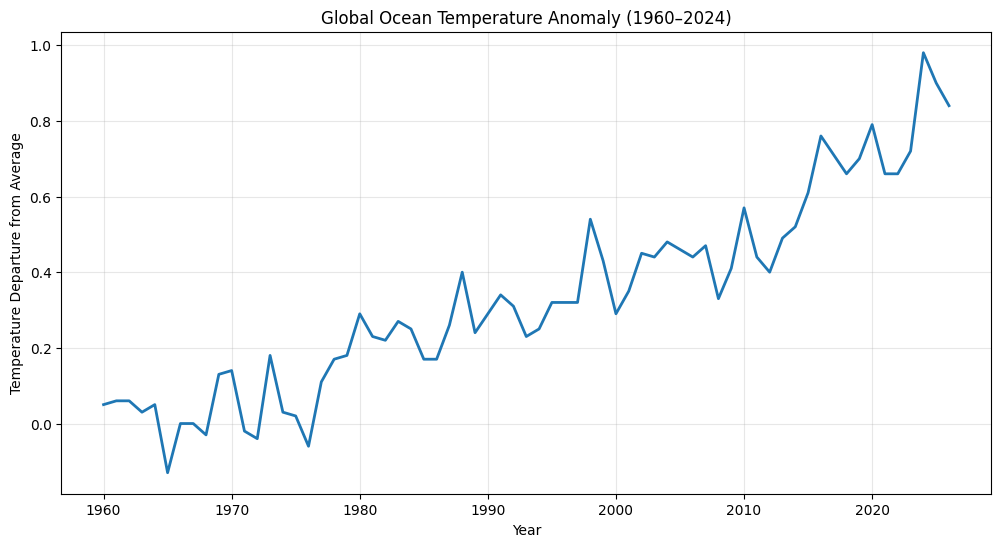

In [147]:
plt.figure(figsize=(12, 6))

plt.plot(ocean_temp_df["Year"], ocean_temp_df["Temp_Anomaly"], linewidth=2)

plt.title("Global Ocean Temperature Anomaly (1960–2024)")
plt.xlabel("Year")
plt.ylabel("Temperature Departure from Average")
plt.grid(alpha=0.3)

plt.show()

### Ocean Temperature Anomaly Plot Interpretation

Global ocean temperatures show a clear long-term warming trend.

This provides an environmental context for the shark incident analysis. As sharks are marine animals, their behavior is influenced by coean conditions, including potentially ocean temperatures. 

This does not establish a CAUSAL relationship between warming ocean temperatures and shark incidents, but it provides a useful environmental variable to compare against long-term incident patterns.

In [155]:
climate_risk_df = pd.merge(merged_df, ocean_temp_df, on = 'Year', how = 'inner')

In [156]:
climate_risk_df.head()

,Year,Attack Count,Population,Attacks_per_100k,Rolling_5yr,Temp_Anomaly
0,1960,6,5004000,0.119904,NaN,0.05
1,1961,8,5243000,0.152584,NaN,0.06
2,1962,5,5458000,0.091609,NaN,0.06
3,1963,6,5628000,0.106610,NaN,0.03
4,1964,8,5781000,0.138384,0.121818,0.05


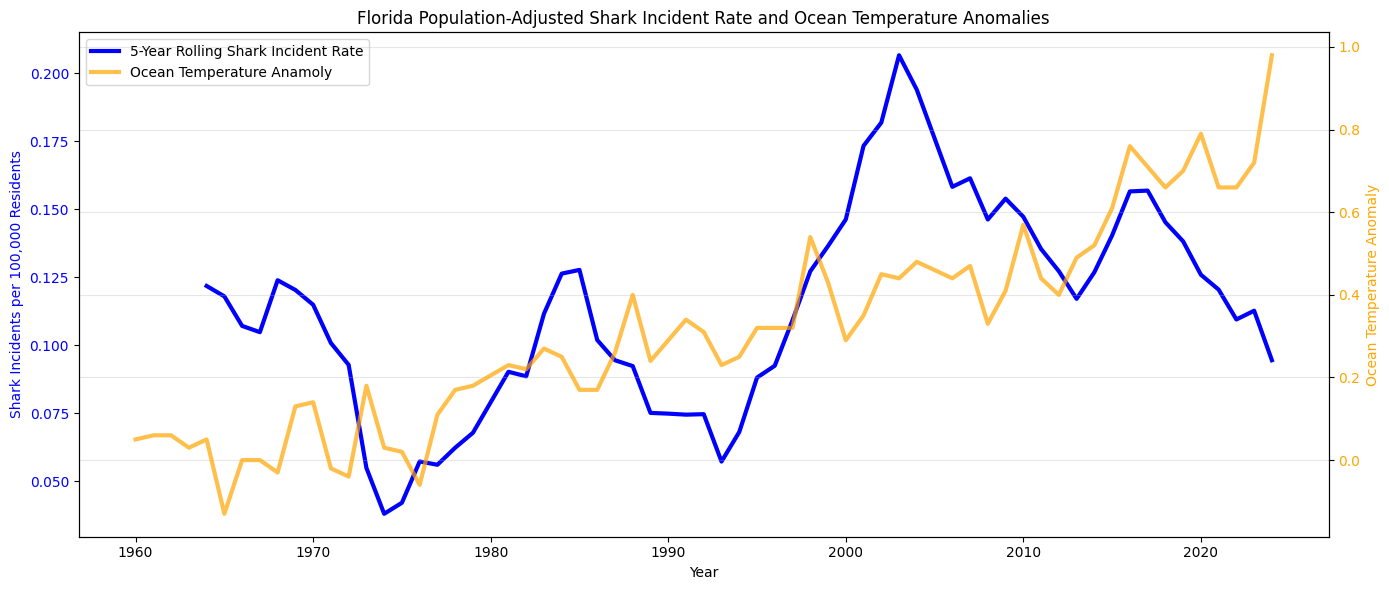

In [166]:
fig, ax1 = plt.subplots(figsize=(14,6))

line1 = ax1.plot(climate_risk_df['Year'], climate_risk_df['Rolling_5yr'],linewidth=3, color = 'blue', label = '5-Year Rolling Shark Incident Rate')

ax1.set_xlabel('Year')
ax1.set_ylabel("Shark Incidents per 100,000 Residents", color = 'blue')
ax1.tick_params(axis = 'y', labelcolor = 'blue')

ax2 = ax1.twinx()

line2 = ax2.plot(climate_risk_df['Year'], climate_risk_df['Temp_Anomaly'], linewidth = 3, alpha = 0.7, color = 'orange', label = "Ocean Temperature Anamoly")
ax2.set_ylabel("Ocean Temperature Anomaly", color = 'orange')
ax2.tick_params(axis = 'y', labelcolor = 'orange')

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(alpha = 0.3)
plt.title("Florida Population-Adjusted Shark Incident Rate and Ocean Temperature Anomalies")
plt.tight_layout()
plt.show()

## Florida Shark Incident Rate and Ocean Temperature Anomalies Over Time Interpretation

Ocean temperature anomalies show a strong long-term warming trend across the study period, especially after the late 20th-century.

In contrast, Florida's population-adjusted shark incident rate displays variability across decades rather than a continuous upward trend. Increased incident frequency appears to increase during certain periods - especially in the late 1990s and early 2000s - but later moderates despite continued ocean warming. 

This suggests that shark incident patterns are shaped by multiple interacting environmental and human factors rather than temperature alone. Population exposure, tourism activity, coastal recreation, reporting practices, etc. likely all contribute to long-term incident variability. 

## Conclusion

## 1. Raw shark incident trends
### shark incident totals generally increase over time
The raw shark attack data and plots create the intuitive narrative that "shark attacks are increasing."

## 2. Population-adjusted Florida anlysis
### The previous notion regarding increasing attacks is challenged
Instead of continous increase, the population-adjusted plot shows that there is a high rate of variability to shark incidents, which suggests that 
### population growth explains part of the increase in raw shark incidents.

### The rolling average plot supports this finding
The rolling average graph says that once yearly noise is smoothed out, there is still not a simple long-term increase in relative risk of shark attack.

## 3. Ocean temperature and shark incident trends
### the ocean temperature anomaly plot showed a clear upwards trend
That is a real environmental trend

### however, when compared against shark attack data...
The relationship is NOT "higher shark attack frequency is caused by temperature rise alone." Instead, temperatures rise yet shark incident risk fluctuates. 

### Therefore, shark incidents likely reflect multiple interacting enviornmental and human factors other than population and ocean temperatures rising such as tourism and coastal patterns, reporting practices, shark killing, and more.
